In [2]:
# Import module constrained_likelihood_surrogates
#
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *

In [3]:

## CITIES ##


In [4]:
# Load city data

population_list_dict = {}
country_list = ['Australia', 'Brazil', 'Germany', 'UK', 'USA']

# Australia:
country = country_list[0]
with open('../data/cities/australia-top2021.dat', 'r', encoding='utf-8') as file:
    reader = csv.DictReader(file, delimiter='\t')
    city_dict = list(reader)
#     city_list = [entry['SUA'] for entry in city_dict]
#     population_list = [int(entry['Population']) for entry in city_dict]
    city_list = [entry['SUA'] for entry in city_dict if not (entry['SUA'][:34] == 'Not in any Significant Urban Area ')]
    population_list = [int(entry['Population']) for entry in city_dict if not (entry['SUA'][:34] == 'Not in any Significant Urban Area ')]
    population_list_dict[country] = population_list
    
# Brazil:
country = country_list[1]
with open('../data/cities/brazil-population-1996-2012.dat', 'r', encoding='utf-8') as file:
    reader = csv.DictReader(file, delimiter=';')
    city_dict = list(reader)
    year_str = '2012'#2012 population
#     city_list = [entry['Município'] for entry in city_dict if entry[year_str].isnumeric() and (int(entry[year_str]) >= 10**4) and not (entry['Município'] == 'Total')]
#     population_list = [int(entry[year_str]) for entry in city_dict if entry[year_str].isnumeric() and (int(entry[year_str]) >= 10**4) and not (entry['Município'] == 'Total')]
    city_list = [entry['Município'] for entry in city_dict if entry[year_str].isnumeric() and not (entry['Município'] == 'Total')]
    population_list = [int(entry[year_str]) for entry in city_dict if entry[year_str].isnumeric() and not (entry['Município'] == 'Total')]
    population_list_dict[country] = population_list
    
# Germany:
country = country_list[2]
with open('../data/cities/germany-GERcity_gdp_pop_2012.dat', 'r', encoding='utf-8') as file:
    reader = csv.DictReader(file, delimiter='\t')
    city_dict = list(reader)
    city_list = [entry['city'] for entry in city_dict]
    population_list = [int(entry['population']) for entry in city_dict]
    population_list_dict[country] = population_list

# UK:
country = country_list[3]
with open('../data/cities/uk-SumsP50D14F30.dat', 'r', encoding='utf-8') as file:
    reader = csv.DictReader(file, delimiter='\t')
    city_dict = list(reader)
    city_list = [entry['ClusterID'] for entry in city_dict]
    population_list = [int(np.round(float(entry['AllPeople']))) for entry in city_dict]
    population_list_dict[country] = population_list
    
# USA:
country = country_list[4]
with open('../data/cities/usa-USmetro_gdp_pop_2013.dat', 'r', encoding='utf-8') as file:
    reader = csv.DictReader(file, delimiter='\t')
    city_dict = list(reader)
    city_list = [entry['city'] for entry in city_dict]
    population_list = [int(entry['population']) for entry in city_dict]
    population_list_dict[country] = population_list

In [5]:
#Set lower cutoffs for each country:

lower_cutoff_type = 'various'#Lower cutoffs except for Brazil's set to minimum observed value - 0.5; Brazil's set to 9999.5 (following Statistical Laws of Complex Systems by Eduardo G Altmann (2025))
ks_method = 'sup'#Arbitrary - set for repeatability
ecdf_method = 'max'#Arbitrary - set for repeatability

lower_cutoff_hat_dict = {'Australia': [10544.5, 10544.5, 10544.5, 10544.5, 10544.5], 'Brazil': [9999.5, 9999.5, 9999.5, 9999.5, 9999.5], 'Germany': [33741.5, 33741.5, 33741.5, 33741.5, 33741.5], 'UK': [50029.5, 50029.5, 50029.5, 50029.5, 50029.5], 'USA': [54060.5, 54060.5, 54060.5, 54060.5, 54060.5]}
process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
country_list = list(lower_cutoff_hat_dict.keys())

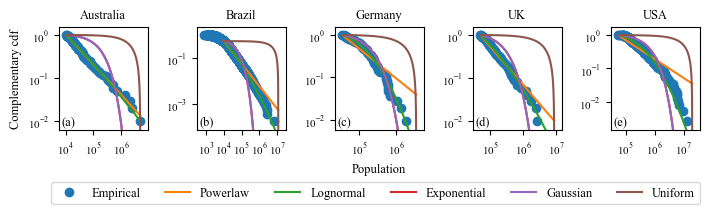

In [10]:
# Plot fits from different models:
model_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
k_list = [1, 2, 1, 2, 1]#Number of parameters
# model_list = ['powerlaw', 'lognorm']
# k_list = [1, 2]#Number of parameters
num_models = len(model_list)

num_countries = len(country_list)
fig, ax_list = plt.subplots(1, num_countries, figsize=(7, 1.9))

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style

for i_country in range(num_countries):
    ax = ax_list[i_country]
    country = country_list[i_country]
    lower_cutoff_hat_list = lower_cutoff_hat_dict[country]
    val_seq_0 = population_list_dict[country]
    N_0 = len(val_seq_0)

    N_list = []
    param_hat_list = []
    
    eval_points, emp_cdf = ecdf_2(val_seq_0, method=ecdf_method)
    emp_ccdf = [1 - y for y in emp_cdf]
    emp_ccdf_array = np.array(emp_ccdf)
    min_emp_ccdf = np.min(emp_ccdf_array[emp_ccdf_array > 0])
    max_emp_ccdf = np.max(emp_ccdf_array)
    ratio_max_min_emp_ccdf = max_emp_ccdf/min_emp_ccdf
    ax.plot(eval_points, emp_ccdf, 'o', label='Empirical')#sf = 1 - cdf
    for i_model in range(num_models):
        model = model_list[i_model]
        k = k_list[i_model]
        lower_cutoff_hat = lower_cutoff_hat_list[i_model]
        val_seq = [val for val in val_seq_0 if (val >= lower_cutoff_hat)]
        N = len(val_seq)
        N_list = N_list + [N]
        num_trans = N*(int(np.ceil(np.log2(N*1024))))
        val_seq_1 = val_seq
        param_hat, lp_seq = fit_model(val_seq, model=model, lower_cutoff_hat=lower_cutoff_hat)
        BIC = (-2*sum(lp_seq) + np.log(N)*k)/N
        param_hat_list = param_hat_list + [param_hat]
    
        #x = np.exp(np.arange(np.log(lower_cutoff_hat), np.log(np.max(val_seq)) + 0.05, 0.1))
        if (model == 'powerlaw'):
            lambda_hat = param_hat[0]
            fit_ccdf_fun = lambda seq : expon.sf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)
            fit_iccdf_fun = lambda p_seq : np.exp(expon.isf(p_seq, loc=np.log(lower_cutoff_hat), scale=1/lambda_hat))
        elif (model == 'lognorm'):#Truncated lognormal distribution
            if (not np.isinf(param_hat[1])):#Could fit lognormal using maximum likelihood
                mu_hat, sigma_hat = param_hat[0], param_hat[1]
                fit_ccdf_fun = lambda seq : truncnorm.sf((np.log(seq) - mu_hat)/sigma_hat, (np.log(lower_cutoff_hat) - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat)
                fit_iccdf_fun = lambda p_seq : np.exp(truncnorm.isf(p_seq, (np.log(lower_cutoff_hat) - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat)*sigma_hat + mu_hat)
            else:#Could not fit lognormal using maximum likelihood: consider powerlaw instead
                lambda_hat = param_hat[0]
                fit_ccdf_fun = lambda seq : expon.sf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)
                fit_iccdf_fun = lambda p_seq : np.exp(expon.isf(p_seq, loc=np.log(lower_cutoff_hat), scale=1/lambda_hat))
        elif (model == 'expon'):#Exponential distribution
            lambda_hat = param_hat[0]
            fit_ccdf_fun = lambda seq : expon.sf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
            fit_iccdf_fun = lambda p_seq : expon.isf(p_seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
        elif (model == 'truncnorm'):#Truncated Gaussian distribution
            if (not np.isinf(param_hat[1])):#Could fit truncated normal using maximum likelihood
                mu_hat, sigma_hat = param_hat[0], param_hat[1]
                fit_ccdf_fun = lambda seq : truncnorm.sf((seq - mu_hat)/sigma_hat, (lower_cutoff_hat - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat)
                fit_iccdf_fun = lambda p_seq : truncnorm.isf(p_seq, (lower_cutoff_hat - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat)*sigma_hat + mu_hat
            else:#Could not fit truncated normal using maximum likelihood: consider exponential instead
                lambda_hat = param_hat[0]
                fit_ccdf_fun = lambda seq : expon.sf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
                fit_iccdf_fun = lambda p_seq : expon.isf(p_seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
        elif (model == 'uniform'):#Uniform distribution
            b_hat = param_hat[0]
            a = lower_cutoff_hat
            fit_ccdf_fun = lambda seq : uniform.sf(seq, loc=a, scale=(b_hat - a))
            fit_iccdf_fun = lambda p_seq : uniform.isf(p_seq, loc=a, scale=(b_hat - a))
        else:
            raise Exception('model=' + str(model) + ' not recognised.')
    
        x = np.arange(lower_cutoff_hat, np.max(val_seq) + 0.5)
        fit_ccdf = fit_ccdf_fun(x)
    
        ax.plot(x, N/N_0*fit_ccdf, label=beautify_distribution_name(model))#sf = 1 - cdf
    min_val_0 = min(val_seq_0)
    max_val_0 = max(val_seq_0)
    ratio_max_min_val_0 = max_val_0/min_val_0
    max_val_0 = max(val_seq_0)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xticks([10**n for n in range(10)])
    ax.set_title(country)
    ax.set_xlim([min_val_0*ratio_max_min_val_0**-0.1, max_val_0*ratio_max_min_val_0**+0.1])
    ax.set_ylim([min_emp_ccdf*ratio_max_min_emp_ccdf**-0.1, max_emp_ccdf*ratio_max_min_emp_ccdf**+0.1])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
ax = ax_list[2]
ax.set_xlabel('Population')
ax_list[0].set_ylabel('Complementary cdf')
fig.tight_layout()
ax.legend(ncol=6, loc='lower center', bbox_to_anchor=(0.46, -0.78))
label_subplots(ax_list, corner='lower left', order='row-major')

bbox = fig.get_tightbbox(fig.canvas.get_renderer())
scale = fig.get_figwidth()/bbox.width
fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

plt.savefig('figures\\' + 'cities-fits-' + str(num_models) + '-models' + '.pdf', bbox_inches='tight')
plt.savefig('figures\\' + 'cities-fits-' + str(num_models) + '-models' + '.png', bbox_inches='tight')
plt.show()

In [7]:
# Hypothesis testing of city data
# 
sp = '  '#Making indentations to increase readability 
test_type = 'rejection'
num_surr = 9

if ('ave' in lower_cutoff_type):
    ks_method = 'ave'
elif ('sup' in lower_cutoff_type):
    ks_method = 'sup'

num_countries = len(country_list)
num_tests = num_countries

print(str(num_tests) + ' tests, each with ' + str(num_surr) + ' constrained, typical surrogates')

# null_model_list = ['powerlaw', 'lognorm']
null_model_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_null_models = len(null_model_list)
cutoff_dict_list = [lower_cutoff_hat_dict]*num_null_models

num_methods = 2#Based on constrained + KS, typical + KS

quantile_list_list_list = np.full((num_methods, num_null_models, num_countries), np.nan)#Array of nans: num_methods x num_null_models x num_tests
save_str_0 = 'quant' + '_' + test_type + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_nmod-' + str(num_null_models)+ '_ks-' + str(ks_method)

data_str = '_city-sizes-ega' + '_lower-cutoff-type-' + str(lower_cutoff_type)

N_list = [np.nan for i_country in range(num_countries)]
N_mat = np.full((num_countries, num_null_models), 0)#Array of nans: num_null_models x num_tests
num_trans_mat = np.full((num_countries, num_null_models), 0)#Array of nans: num_null_models x num_tests

start_time = timer()

for i_country in range(num_countries):
    country = country_list[i_country]
    start_time_country = timer()
    val_seq = population_list_dict[country]
    N = len(val_seq)
    N_list[i_country] = N#List of lengths of time series for each null model
    print('Considering ' + country + ': N = ' + str(N) + ' cities')
    N_null_list = []#Length 
    param_hat_null_list = []#List of max. likelihood parameters for each null model
    lp_seq_null_list = []#List of max. likelihood log probability values for each null model
    val_seq_null_list = []#List of time series for each null model
    ks_list = []#List of time series for each null model
    for i_null_model in range(num_null_models):
        null_model = null_model_list[i_null_model]
        i_null_model_2 = np.where(np.array(process_list) == null_model)[0][0]
        cutoff_dict_null = cutoff_dict_list[i_null_model]
        lower_cutoff_hat_null = cutoff_dict_null[country][i_null_model_2]
        val_seq_null = [val for val in val_seq if (val >= lower_cutoff_hat_null)]
        val_seq_null_list = val_seq_null_list + [val_seq_null]
        N_null = len(val_seq_null)
        N_null_list = N_null_list + [N_null]
        N_mat[i_country, i_null_model] = N_null
        param_hat_null, lp_seq_null = fit_model(val_seq_null, lower_cutoff_hat=lower_cutoff_hat_null, model=null_model)
        param_hat_null_list = param_hat_null_list + [param_hat_null]
        lp_seq_null_list = lp_seq_null_list + [lp_seq_null]
        ks = calc_ks(val_seq_null, model=null_model, lower_cutoff_hat=lower_cutoff_hat_null, param_hat=param_hat_null, ks_method=ks_method)
        ks_list = ks_list + [ks]
    for i_null_model in range(num_null_models):
        start_time_null_model = timer()
        null_model = null_model_list[i_null_model]
        i_null_model_2 = np.where(np.array(process_list) == null_model)[0][0]
        cutoff_dict_null = cutoff_dict_list[i_null_model]
        lower_cutoff_hat_null = cutoff_dict_null[country][i_null_model_2]
        val_seq_null = val_seq_null_list[i_null_model]
        N_null = len(val_seq_null)
        print(1*sp + 'Null model for largest N_null = ' + str(N_null) + ' data is ' + null_model + ' with lower cutoff ' + str(lower_cutoff_hat_null))
        if (N_null > 0):
            num_trans = N_null*(int(np.ceil(np.log2(N_null*1024))))
        else:
            num_trans = 0
            print(1*sp + 'Skipping ' + null_model + ' null model')
            continue
        num_trans_mat[i_country, i_null_model] = num_trans
        param_hat_null = param_hat_null_list[i_null_model]
        ks = ks_list[i_null_model]
        c_surr_null_val_seq = val_seq_null
        c_surr_ks_list = []#
        t_surr_ks_list = []#
        for i_surr in range(num_surr):
            c_surr_null_val_seq = gen_surrogate(c_surr_null_val_seq, model=null_model, method='constrained', num_trans=num_trans, lower_cutoff_hat=lower_cutoff_hat_null, param_hat=param_hat_null)
            t_surr_null_val_seq = gen_surrogate(val_seq_null, model=null_model, method='typical', num_trans=num_trans, lower_cutoff_hat=lower_cutoff_hat_null, param_hat=param_hat_null)
            for i_method in range(num_methods):
                if (i_method == 0):#Constrained surrogates
                    surr_null_val_seq = c_surr_null_val_seq
                elif (i_method == 1):#Typical surrogates
                    surr_null_val_seq = t_surr_null_val_seq
                surr_param_hat_null, surr_lp_seq_null = fit_model(surr_null_val_seq, lower_cutoff_hat=lower_cutoff_hat_null, model=null_model)
                surr_ks = calc_ks(surr_null_val_seq, model=null_model, lower_cutoff_hat=lower_cutoff_hat_null, param_hat=surr_param_hat_null, ks_method=ks_method)
                if (i_method == 0):#Constrained surrogates
                    c_surr_ks_list = c_surr_ks_list + [surr_ks]
                elif (i_method == 1):#Typical surrogates
                    t_surr_ks_list = t_surr_ks_list + [surr_ks]
        end_time_null_model = timer()
        total_time_null_model = end_time_null_model - start_time_null_model
        print(sp + 'Null model ' + str(null_model) + ' took ' + str(total_time_null_model) + 'sec.')
        for i_method in range(num_methods):
            obs_stat = ks
            abs_obs_stat = abs(obs_stat)#Add small random perturbations to avoid ties
            if (abs_obs_stat == np.inf):
                abs_obs_stat = 0
            obs_stat = obs_stat + 10**-6*abs_obs_stat*(np.random.uniform() - 0.5)
            if (i_method == 0):#KS distance with constrained surrogates
                stat_val_surr_list = np.array(c_surr_ks_list)
            if (i_method == 1):#KS distance with typical surrogates
                stat_val_surr_list = np.array(t_surr_ks_list)
            stat_val_surr_list = stat_val_surr_list + 10**-6*abs_obs_stat*(np.random.uniform(size=num_surr) - 0.5)#Add small random perturbations to avoid ties
            #Work out rank of observed statistic (position of statistic corresponding to observed sequence when statistics corresponding to observed sequence and surrogate sequences are ranked from smallest to largest)
            rankMin = 1 + sum(stat_val_surr_list < obs_stat)
            rankMax = 1 + sum(stat_val_surr_list <= obs_stat)
            r = random.randint(rankMin, rankMax)
            q = (r - 0.5)/(num_surr + 1)
            quantile_list_list_list[i_method, i_null_model, i_country] = q
        print(1*sp + 'Using [KS (constrained), KS (typical)]:')
        quantile_list = quantile_list_list_list[:, i_null_model, i_country].tolist()
        print(1*sp + str(quantile_list))
    end_time_country = timer()
    total_time_country = end_time_country - start_time_country
    print('Country number ' + str(i_country) + ' took ' + str(total_time_country) + 'sec.')

end_time = timer()
total_time = end_time - start_time

save_str = save_str_0 + data_str

save_dict = {'quantile_list_list_list':quantile_list_list_list.tolist(),
             'country_list':list(country_list),
             'test_type':test_type,
             'lower_cutoff_type':lower_cutoff_type,
             'lower_cutoff_hat_dict':lower_cutoff_hat_dict,
             'cutoff_dict_list':cutoff_dict_list,
             'N_list':N_list,
             'N_mat':N_mat.tolist(),
             'num_trans_mat':num_trans_mat.tolist(),
             'num_surr':num_surr,
             'num_tests':num_tests,
             'num_methods':num_methods,
             'process_list':process_list,
             'null_model_list':null_model_list,
             'data_str':data_str,
             'ks_method':ks_method,
             'save_str':save_str,
             'total_time':total_time,
}

save('./results/hyp-test/cities/' + save_str, save_dict)

5 tests, each with 9 constrained, typical surrogates
Considering Australia: N = 102 cities
  Null model for largest N_null = 102 data is powerlaw with lower cutoff 10544.5
  Null model powerlaw took 0.15819420001935214sec.
  Using [KS (constrained), KS (typical)]:
  [0.55, 0.75]
  Null model for largest N_null = 102 data is lognorm with lower cutoff 10544.5
  Null model lognorm took 0.6407766999909654sec.
  Using [KS (constrained), KS (typical)]:
  [0.65, 0.85]
  Null model for largest N_null = 102 data is expon with lower cutoff 10544.5
  Null model expon took 0.1542201000265777sec.
  Using [KS (constrained), KS (typical)]:
  [0.95, 0.95]
  Null model for largest N_null = 102 data is truncnorm with lower cutoff 10544.5
  Null model truncnorm took 0.8163229000056162sec.
  Using [KS (constrained), KS (typical)]:
  [0.95, 0.95]
  Null model for largest N_null = 102 data is uniform with lower cutoff 10544.5
  Null model uniform took 0.0077133000013418496sec.
  Using [KS (constrained), KS 

In [8]:
# Showing results for city data
# 
save_str = 'quant_rejection_nsur-999_ntes-5_ntyp-2_nmod-5_ks-sup_city-sizes-ega_lower-cutoff-type-various'
with open('./results/hyp-test/cities/' + save_str + '.json', 'r') as read_file:
    save_dict = json.load(read_file)

quantile_list_list_list = np.array(save_dict['quantile_list_list_list'])
country_list = save_dict['country_list']
test_type = save_dict['test_type']
lower_cutoff_type = save_dict['lower_cutoff_type']
lower_cutoff_hat_dict = save_dict['lower_cutoff_hat_dict']
cutoff_dict_list = save_dict['cutoff_dict_list']
N_list = save_dict['N_list']
N_mat = np.array(save_dict['N_mat'])
num_trans_mat = np.array(save_dict['num_trans_mat'])
num_surr = save_dict['num_surr']
num_tests = save_dict['num_tests']
num_methods = save_dict['num_methods']
process_list = save_dict['process_list']
null_model_list = save_dict['null_model_list']
data_str = save_dict['data_str']
ks_method = save_dict['ks_method']
save_str = save_dict['save_str']
total_time = save_dict['total_time']

num_countries = len(country_list)
print('KS distance with constrained or typical surrogates')
for i_country in range(num_countries):
    country = country_list[i_country]
    print('\t' + country)
    for i_method in range(num_methods):#Hypothesis tests using KS distance based on [constrained, typical] surrogates
        if (i_method == 0):
            print('\t\tConstrained surrogates')
        elif (i_method == 1):
            print('\t\tTypical surrogates')
        q_list = quantile_list_list_list[i_method, :, i_country]
        p_list = 1 - q_list
        print('\t\t\t' + str(p_list))

KS distance with constrained or typical surrogates
	Australia
		Constrained surrogates
			[0.3535 0.3405 0.0005 0.0005 0.0005]
		Typical surrogates
			[0.3725 0.3605 0.0005 0.0005 0.0005]
	Brazil
		Constrained surrogates
			[0.0005 0.0005 0.0005 0.0005 0.0005]
		Typical surrogates
			[0.0005 0.0005 0.0005 0.0005 0.0005]
	Germany
		Constrained surrogates
			[5.000e-04 5.885e-01 9.500e-03 1.245e-01 5.000e-04]
		Typical surrogates
			[5.000e-04 6.035e-01 5.000e-04 2.425e-01 5.000e-04]
	UK
		Constrained surrogates
			[0.0575 0.3195 0.0005 0.0015 0.0005]
		Typical surrogates
			[0.0595 0.3425 0.0005 0.0005 0.0005]
	USA
		Constrained surrogates
			[0.0005 0.0005 0.0005 0.0005 0.0005]
		Typical surrogates
			[0.0005 0.0005 0.0005 0.0005 0.0005]
